# House Price Prediction: Ames, Iowa

**Problem:** Estimate the sale price of a house from its features (size, quality, location, age...), so a seller or agent can set a fair listing price.

**Data:** 1,460 house sales in Ames, Iowa (2006-2010), 79 features. Source: Kaggle "House Prices - Advanced Regression Techniques".

**Metric:** RMSE on log price. It treats a 10% miss on a cheap house and on an expensive house the same.

**Result:** A Lasso regression model predicts prices with a typical error of about 11-12%. On a held-out test set: RMSE 0.116 (log), average miss about $13.8k per house, R² 0.92 (log price).

In [1]:
# Imports and data


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# one row per house sold; data file not included in the repo (see README for the Kaggle link)
df = pd.read_csv("../data/train.csv")
print(df.shape)

(1460, 81)


## 1. The target: sale price

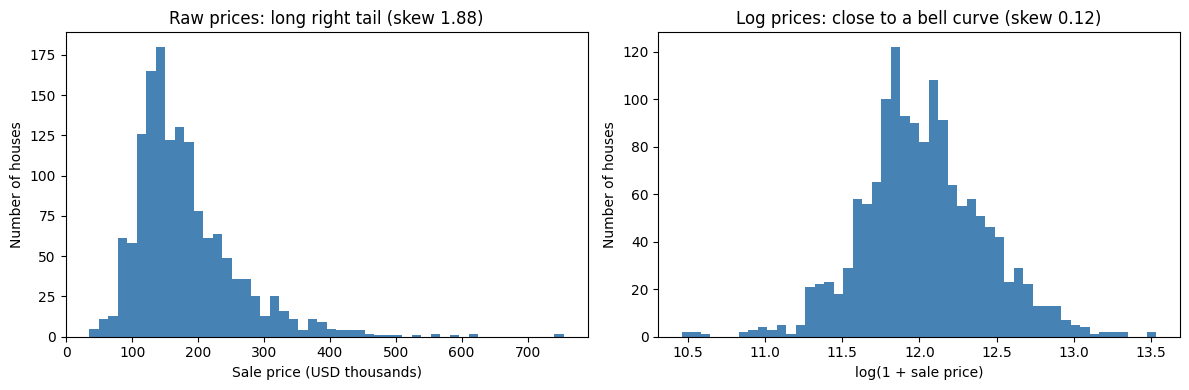

In [2]:
# Price before and after log

# left: raw prices, right: log prices, same number of bins so they compare fairly
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["SalePrice"] / 1000, bins=50, color="steelblue")
ax[0].set_title(f"Raw prices: long right tail (skew {df['SalePrice'].skew():.2f})")
ax[0].set_xlabel("Sale price (USD thousands)")
ax[0].set_ylabel("Number of houses")

ax[1].hist(np.log1p(df["SalePrice"]), bins=50, color="steelblue")
ax[1].set_title(f"Log prices: close to a bell curve (skew {np.log1p(df['SalePrice']).skew():.2f})")
ax[1].set_xlabel("log(1 + sale price)")
ax[1].set_ylabel("Number of houses")

plt.tight_layout()   # stops the two charts' labels from overlapping
plt.show()

**Decision:** raw prices are right-skewed (skew 1.88). After log(1 + price) the skew drops to 0.12. I train all models on log price and convert predictions back to dollars with expm1. This also matches the competition metric (RMSE on log price).

## 2. What drives the price

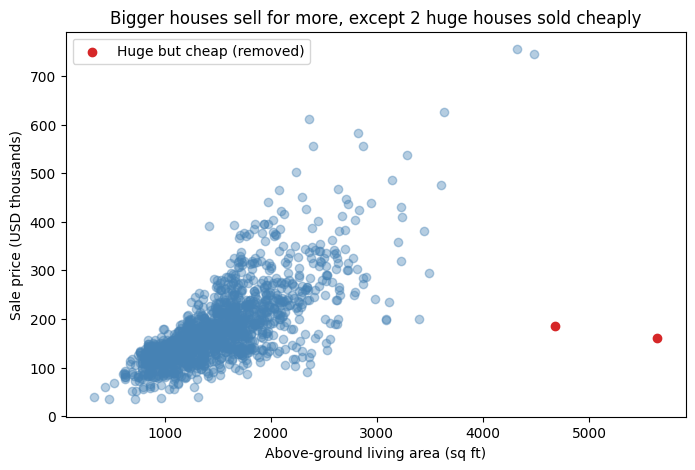

In [3]:
# Living area vs price

# very large houses that sold cheap; the dataset's author recommends removing them
odd = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.loc[~odd, "GrLivArea"], df.loc[~odd, "SalePrice"] / 1000, alpha=0.4, color="steelblue")
ax.scatter(df.loc[odd, "GrLivArea"], df.loc[odd, "SalePrice"] / 1000, color="tab:red", label="Huge but cheap (removed)")
ax.set_title("Bigger houses sell for more, except 2 huge houses sold cheaply")
ax.set_xlabel("Above-ground living area (sq ft)")
ax.set_ylabel("Sale price (USD thousands)")
ax.legend()
plt.show()

**Decision:** living area rises with price in a clear trend. Two houses over 4,000 sq ft sold far below that trend (both were unusual sales). I remove these 2 rows before training, because they would pull the fitted line down for every large house.

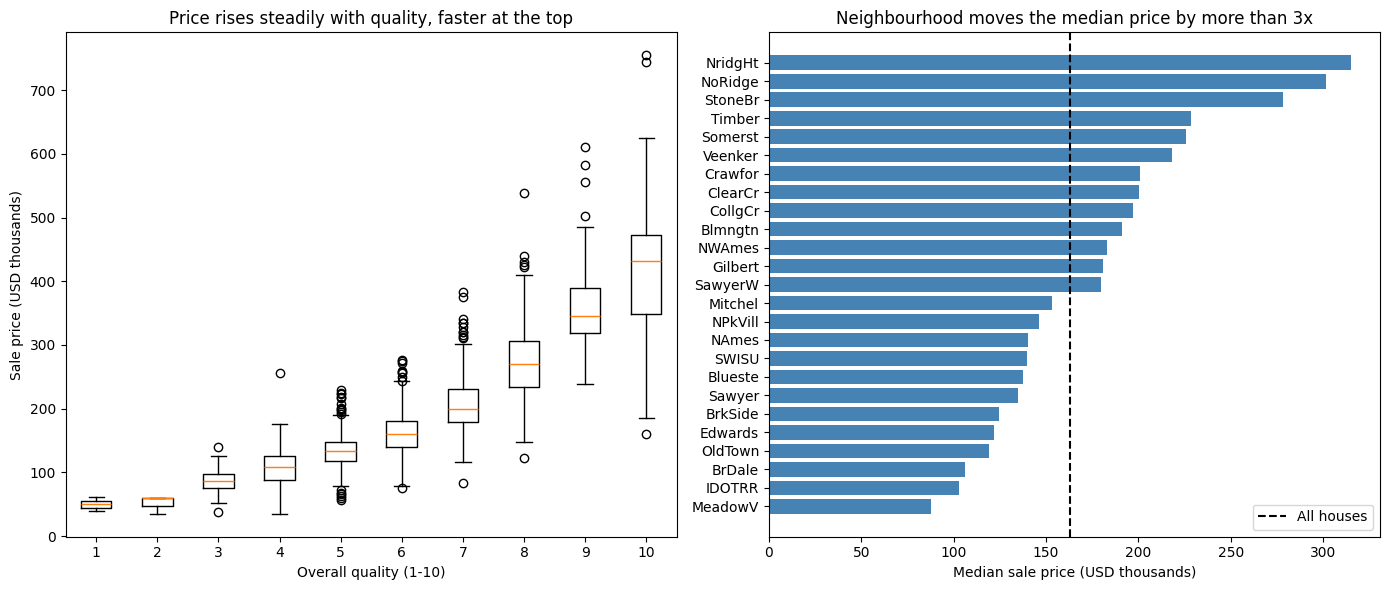

In [4]:
# Price by quality and by neighbourhood

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# left: one box of prices per quality grade (1 = very poor, 10 = very excellent)
levels = sorted(df["OverallQual"].unique())
groups = [df.loc[df["OverallQual"] == q, "SalePrice"] / 1000 for q in levels]
ax[0].boxplot(groups, tick_labels=levels)
ax[0].set_title("Price rises steadily with quality, faster at the top")
ax[0].set_xlabel("Overall quality (1-10)")
ax[0].set_ylabel("Sale price (USD thousands)")

# right: median price per neighbourhood, cheapest at the bottom
nbhd = df.groupby("Neighborhood")["SalePrice"].median().sort_values() / 1000
ax[1].barh(nbhd.index, nbhd.values, color="steelblue")
ax[1].axvline(df["SalePrice"].median() / 1000, color="black", linestyle="--", label="All houses")
ax[1].set_title("Neighbourhood moves the median price by more than 3x")
ax[1].set_xlabel("Median sale price (USD thousands)")
ax[1].legend()

plt.tight_layout()
plt.show()

**What I see:** quality and location both move price strongly. Each quality step adds more money than the one before, which fits a log target. The median price in the most expensive neighbourhood is more than 3x the cheapest, so Neighborhood goes into the model as a category.

## 3. Cleaning decisions

Fixes that use no statistics are done here, on the full data. Anything that learns a value from the data (median, most frequent) happens inside the model pipeline, after the train/test split, to avoid data leakage.

In [5]:
# Remove outliers, Id, and the fake gaps

# work on a copy; drop the 2 outliers and Id (a row number, says nothing about price)
data = df[~odd].drop(columns="Id").copy()

# per data_description.txt, NA here means "the house doesn't have it" (no pool, no garage...)
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
data[none_cols] = data[none_cols].fillna("None")
print(data.shape)

(1458, 80)


In [6]:
# no masonry veneer = area 0; GarageYrBlt has no sensible fill for "no garage"
# and is almost the same as YearBuilt, so drop it
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)
data = data.drop(columns="GarageYrBlt")

# MSSubClass codes (20, 60, 70...) are house types, not amounts
data["MSSubClass"] = data["MSSubClass"].astype(str)

# features, log target, and a 20% test set kept aside until the very end
X = data.drop(columns="SalePrice")
y = np.log1p(data["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1166, 78) (292, 78)


## 4. Models

One pipeline prepares the data for every model: numbers get the median for gaps and are scaled; text columns get the most frequent value for gaps and are one-hot encoded. All models are compared with 5-fold cross-validation on the training set only.

In [7]:
# numbers and text are prepared differently
num_cols = X_train.select_dtypes("number").columns
cat_cols = X_train.select_dtypes("object").columns

# values like the median are learned from training folds only (no leakage)
num_steps = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
cat_steps = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))
prep = make_column_transformer((num_steps, num_cols), (cat_steps, cat_cols))

print(len(num_cols), "number columns,", len(cat_cols), "text columns")

34 number columns, 44 text columns


In [8]:
# tuned settings come from the grid searches in 00_exploration.ipynb
models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=30)": Ridge(alpha=30),
    "Lasso (alpha=0.0005)": Lasso(alpha=0.0005, max_iter=50000),
    "XGBoost (depth 2, lr 0.05)": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=2,
                                               subsample=0.8, colsample_bytree=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    scores = -cross_val_score(make_pipeline(prep, model), X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    results[name] = scores.mean()
    print(f"{name}: CV RMSE {scores.mean():.4f} (+/- {scores.std():.4f})")

Baseline (mean): CV RMSE 0.3971 (+/- 0.0184)
Linear Regression: CV RMSE 0.1293 (+/- 0.0116)
Ridge (alpha=30): CV RMSE 0.1134 (+/- 0.0112)
Lasso (alpha=0.0005): CV RMSE 0.1134 (+/- 0.0107)
XGBoost (depth 2, lr 0.05): CV RMSE 0.1184 (+/- 0.0105)


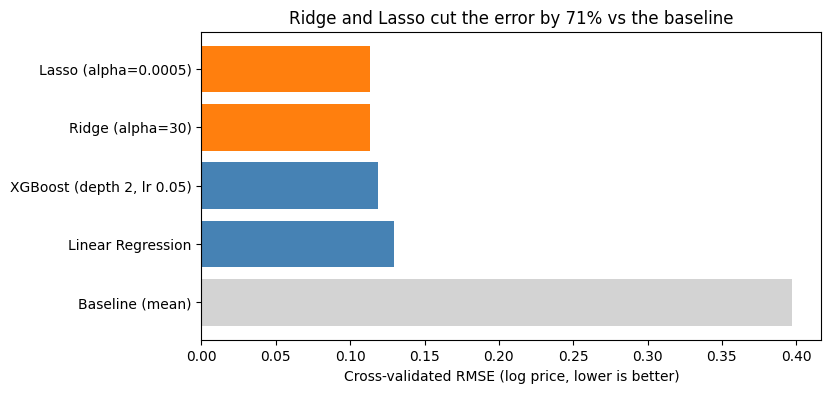

In [9]:
# Chart of the comparison

# lowest error on top; orange = best (Ridge and Lasso tie), grey = baseline
res = pd.Series(results).sort_values(ascending=False)
colors = ["tab:orange" if v <= res.min() + 0.0005 else "lightgrey" if "Baseline" in k else "steelblue"
          for k, v in res.items()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(res.index, res.values, color=colors)
ax.set_title("Ridge and Lasso cut the error by 71% vs the baseline")
ax.set_xlabel("Cross-validated RMSE (log price, lower is better)")
plt.show()

In [10]:
# Fit the chosen model and check its size

# Ridge and Lasso tie on CV RMSE, so check how many features Lasso actually uses
final_model = make_pipeline(prep, Lasso(alpha=0.0005, max_iter=50000))
final_model.fit(X_train, y_train)

# coefficient per feature after one-hot encoding; 0 means Lasso dropped it
coefs = pd.Series(final_model[-1].coef_, index=final_model[0].get_feature_names_out())
coefs.index = coefs.index.str.split("__").str[1]
print("Features kept:", (coefs != 0).sum(), "of", len(coefs))

Features kept: 115 of 311


**Model choice:** Ridge and Lasso tie (CV RMSE 0.1134, about 71% below the mean baseline). Plain Linear Regression is worse (0.1293), so the penalty helps. Tuned XGBoost (0.1184) did not beat them; its best setting used the shallowest trees, which suggests price depends on features in mostly simple, additive ways.

I choose **Lasso**: same accuracy as Ridge, but it keeps only 115 of 311 features, so it's simpler and easier to explain. This choice was made before touching the test set.

## 5. Final test result

The test set (292 houses) is used once, here, after the model was chosen.

In [11]:
# Test the model once

# predict log price for unseen houses, then convert back to dollars
pred_log = final_model.predict(X_test)
price_true, price_pred = np.expm1(y_test), np.expm1(pred_log)

print("Test RMSE (log):", round(root_mean_squared_error(y_test, pred_log), 4))
print("Test MAE ($):   ", round(mean_absolute_error(price_true, price_pred)))
print("Test R2 (log):  ", round(r2_score(y_test, pred_log), 3))

Test RMSE (log): 0.1161
Test MAE ($):    13844
Test R2 (log):   0.92


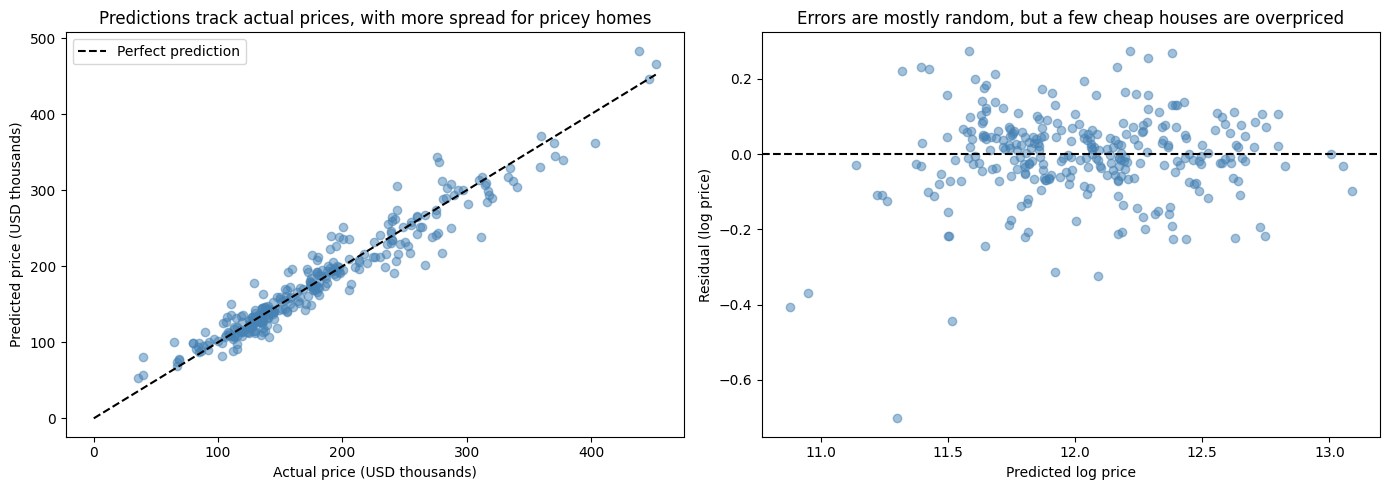

In [12]:
# Actual vs predicted, and residuals


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# left: each dot is a test house; on the dashed line = perfect prediction
ax[0].scatter(price_true / 1000, price_pred / 1000, alpha=0.5, color="steelblue")
lims = [0, price_true.max() / 1000]
ax[0].plot(lims, lims, color="black", linestyle="--", label="Perfect prediction")
ax[0].set_title("Predictions track actual prices, with more spread for pricey homes")
ax[0].set_xlabel("Actual price (USD thousands)")
ax[0].set_ylabel("Predicted price (USD thousands)")
ax[0].legend()

# right: residual = actual - predicted (log); below 0 means the model overpriced the house
residuals = y_test - pred_log
ax[1].scatter(pred_log, residuals, alpha=0.5, color="steelblue")
ax[1].axhline(0, color="black", linestyle="--")
ax[1].set_title("Errors are mostly random, but a few cheap houses are overpriced")
ax[1].set_xlabel("Predicted log price")
ax[1].set_ylabel("Residual (log price)")

plt.tight_layout()
plt.show()

**Result:** test RMSE 0.116 on log price, very close to the CV score (0.113), so the model generalizes to unseen houses. The average miss is about $13.8k per house (roughly 8-9% of the median price). R² is 0.92 on log price.

Most errors sit randomly within ±0.2 of zero. The biggest misses are all overpriced houses at the low end of the market.

## 6. Where the model fails

In [13]:
# The 5 worst predictions



# the 5 test houses with the biggest error, and a few columns that might explain it
worst = residuals.abs().sort_values(ascending=False).head(5).index
check = X_test.loc[worst, ["Neighborhood", "OverallQual", "GrLivArea", "SaleCondition"]].copy()
check["Actual $"] = price_true.loc[worst].round().astype(int)
check["Predicted $"] = pd.Series(price_pred, index=y_test.index).loc[worst].round().astype(int)
check

,Neighborhood,OverallQual,GrLivArea,SaleCondition,Actual $,Predicted $
30,IDOTRR,4,1317,Normal,40000,80738
1432,OldTown,4,968,Normal,64500,100426
916,IDOTRR,2,480,Abnorml,35311,53055
533,BrkSide,1,334,Normal,39300,56889
666,NAmes,6,2380,Abnorml,129000,178469


**What the misses share:** all 5 are overpriced, and 4 of them sold for under $65k: low quality (1-4), very small, in older neighbourhoods (IDOTRR, OldTown, BrkSide). Only 2 of 5 were abnormal sales.

**Why:** there are few very cheap houses to learn from, and regularization pulls extreme predictions toward the average. In real use, I would flag very low-quality houses and abnormal sales for a human check instead of trusting the predicted price.

## 7. What the model learned

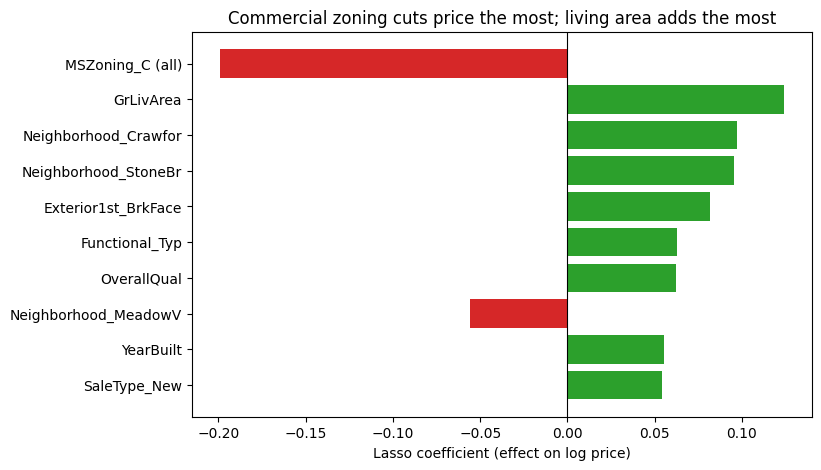

In [14]:
# 10 biggest effects by size, biggest on top; green raises price, red lowers it
top = coefs[coefs.abs().sort_values().index].tail(10)
colors = ["tab:green" if v > 0 else "tab:red" for v in top.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Commercial zoning cuts price the most; living area adds the most")
ax.set_xlabel("Lasso coefficient (effect on log price)")
plt.show()

**Reading the coefficients** (on log price, so +0.10 is roughly +10% price):
- Commercial zoning (MSZoning_C) lowers price the most, about -18%. It's based on only a handful of houses, so treat it with care.
- Living area adds the most: about +500 sq ft means about +13% price.
- Neighbourhood matters: Crawfor and StoneBr about +10%, MeadowV about -5%.
- OverallQual ranks lower than its correlation (0.79) suggests, because related quality columns share its effect (multicollinearity).

Number features are per 1 standard deviation and categories are yes/no, so the bars are only roughly comparable.

### Feature engineering: does it help?

In [15]:
# new features built only from each house's own columns (no statistics), so no leakage
X_train_fe, X_test_fe = X_train.copy(), X_test.copy()

for d in [X_train_fe, X_test_fe]:
    d["TotalSF"] = d["TotalBsmtSF"] + d["1stFlrSF"] + d["2ndFlrSF"]    # all living space in one number
    d["HouseAge"] = d["YrSold"] - d["YearBuilt"]                        # age when sold, not build year
    d["TotalBath"] = d["FullBath"] + 0.5 * d["HalfBath"] + d["BsmtFullBath"] + 0.5 * d["BsmtHalfBath"]

print(X_train_fe[["TotalSF", "HouseAge", "TotalBath"]].describe().round(1))

       TotalSF  HouseAge  TotalBath
count   1166.0    1166.0     1166.0
mean    2557.2      36.9        2.2
std      773.1      30.3        0.8
min      720.0       0.0        1.0
25%     2008.5       8.0        2.0
50%     2475.0      36.0        2.0
75%     2990.8      55.0        2.5
max     6872.0     136.0        6.0


In [16]:
# 3 new number columns, so the pipeline needs an updated column list
num_cols_fe = X_train_fe.select_dtypes("number").columns
prep_fe = make_column_transformer((num_steps, num_cols_fe), (cat_steps, cat_cols))

# same Lasso, same alpha, same 5 folds; only the features changed, so the comparison is fair
lasso_fe = make_pipeline(prep_fe, Lasso(alpha=0.0005, max_iter=50000))
scores = -cross_val_score(lasso_fe, X_train_fe, y_train, cv=5, scoring="neg_root_mean_squared_error")
print(f"Lasso + new features: CV RMSE {scores.mean():.4f} (before: 0.1134)")

Lasso + new features: CV RMSE 0.1135 (before: 0.1134)


**What I see**
- TotalSF, HouseAge, TotalBath: CV RMSE 0.1135 vs 0.1134 before, so no gain. Not kept.
- Reason: each is a sum/difference of existing columns, and a linear model already combines columns that way. They add no new information for Lasso.
- To help a linear model, a feature has to be non-linear (e.g. a log), which the model can't build by adding columns.

### log-transform skewed input features

In [17]:
# find skewed number columns using the training set only
skew = X_train[num_cols].skew()
skewed_cols = skew[skew > 0.75].index

# apply the same log to both sets (log1p keeps 0 as 0)
X_train_log, X_test_log = X_train.copy(), X_test.copy()
X_train_log[skewed_cols] = np.log1p(X_train_log[skewed_cols])
X_test_log[skewed_cols] = np.log1p(X_test_log[skewed_cols])

# same pipeline, Lasso, alpha and folds; only the inputs changed
lasso_log = make_pipeline(prep, Lasso(alpha=0.0005, max_iter=50000))
scores = -cross_val_score(lasso_log, X_train_log, y_train, cv=5, scoring="neg_root_mean_squared_error")
print(len(skewed_cols), "columns logged | CV RMSE", round(scores.mean(), 4), "(before: 0.1134)")

19 columns logged | CV RMSE 0.1124 (before: 0.1134)


### Logged inputs with re-tuned alpha

In [18]:
# same alpha list as the original Lasso tuning, so the comparison is fair
lasso_alphas = [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.01]

# re-tune alpha for the logged inputs; same folds, same metric as before
lasso_log_grid = GridSearchCV(make_pipeline(prep, Lasso(max_iter=50000)),
                              {"lasso__alpha": lasso_alphas}, cv=5, scoring="neg_root_mean_squared_error")
lasso_log_grid.fit(X_train_log, y_train)

print("Best alpha:", lasso_log_grid.best_params_["lasso__alpha"],
      "| CV RMSE:", round(-lasso_log_grid.best_score_, 4), "(target: 0.1114)")

Best alpha: 0.0005 | CV RMSE: 0.1124 (target: 0.1114)


**What I see**
- Re-tuning alpha for the logged inputs picked the same alpha (0.0005) and the same score (0.1124).
- Still above the 0.1114 target set in advance, so I keep the original Lasso without logged inputs.

I also tested feature engineering: summed features (TotalSF, HouseAge, TotalBath) gave no gain, and logging 19 skewed inputs improved CV RMSE by only 0.001 (0.1134 → 0.1124), even after re-tuning alpha, below my threshold of 0.002. Neither was kept.